# Artificial Neural Network (ANN) - Customer Churn Prediction

## Project Overview

This project applies an **Artificial Neural Network (ANN)** to predict whether a bank customer will leave the bank.

The dataset contains customer demographic, account, and behavioral attributes. The target variable, `Exited`, indicates whether a customer churned.

The workflow includes data exploration, feature preparation, preprocessing, neural network training, validation, test-set evaluation, decision-threshold analysis, and error analysis.


## 1. Import Required Libraries


In [23]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


## 2. Load Dataset


In [24]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3. Explore Dataset


In [25]:
print(f"Shape: {df.shape}")
df.info()


Shape: (10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [26]:
display(df.isnull().sum().to_frame("Missing"))
print("Duplicate rows:", df.duplicated().sum())
display(df.describe(include="all").T)


,Missing
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


## 4. Prepare Features and Target

`Exited` is the binary target variable:

- `0` — customer remained with the bank
- `1` — customer exited the bank

`RowNumber`, `CustomerId`, and `Surname` are identifiers rather than meaningful predictive features and are excluded from modeling.


In [27]:
drop_cols = [c for c in ["RowNumber", "CustomerId", "Surname"] if c in df.columns]
model_df = df.drop(columns=drop_cols).copy()
model_df.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 5. Target Distribution

Customer churn is not evenly distributed between the two classes. Examining the target distribution is important because accuracy alone can be misleading when evaluating an imbalanced classification problem.


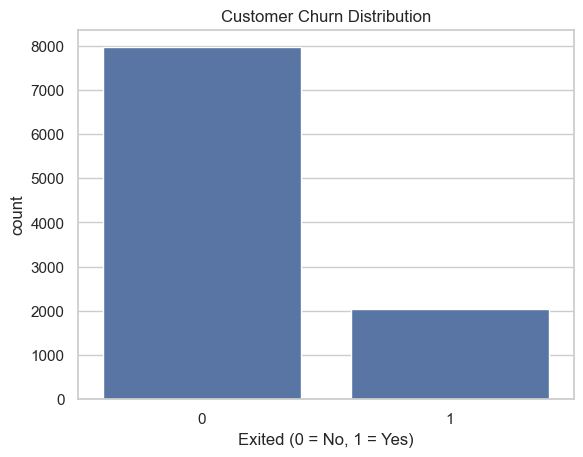

Churn rate: 20.37%


In [28]:
target = "Exited"

sns.countplot(data=model_df, x=target)
plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0 = No, 1 = Yes)")
plt.show()

print(f"Churn rate: {model_df[target].mean():.2%}")


## 6. Exploratory Data Analysis


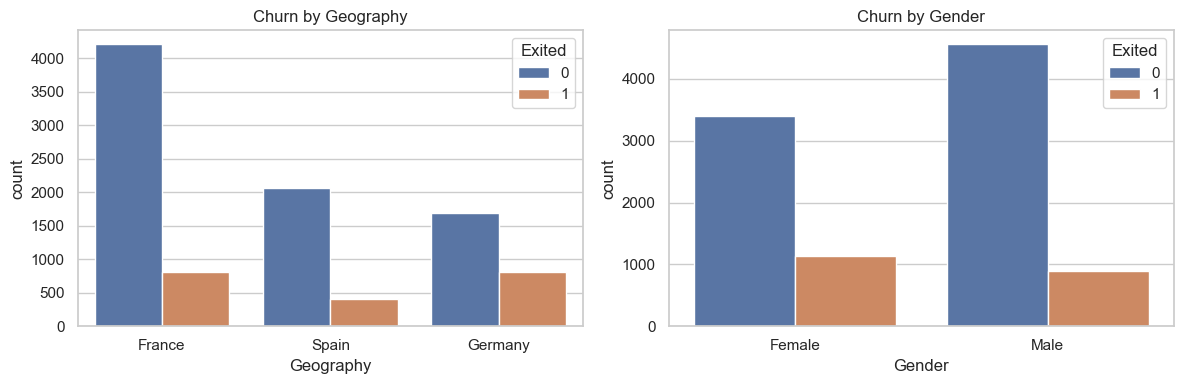

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=model_df, x="Geography", hue=target, ax=axes[0])
axes[0].set_title("Churn by Geography")
sns.countplot(data=model_df, x="Gender", hue=target, ax=axes[1])
axes[1].set_title("Churn by Gender")
plt.tight_layout()
plt.show()


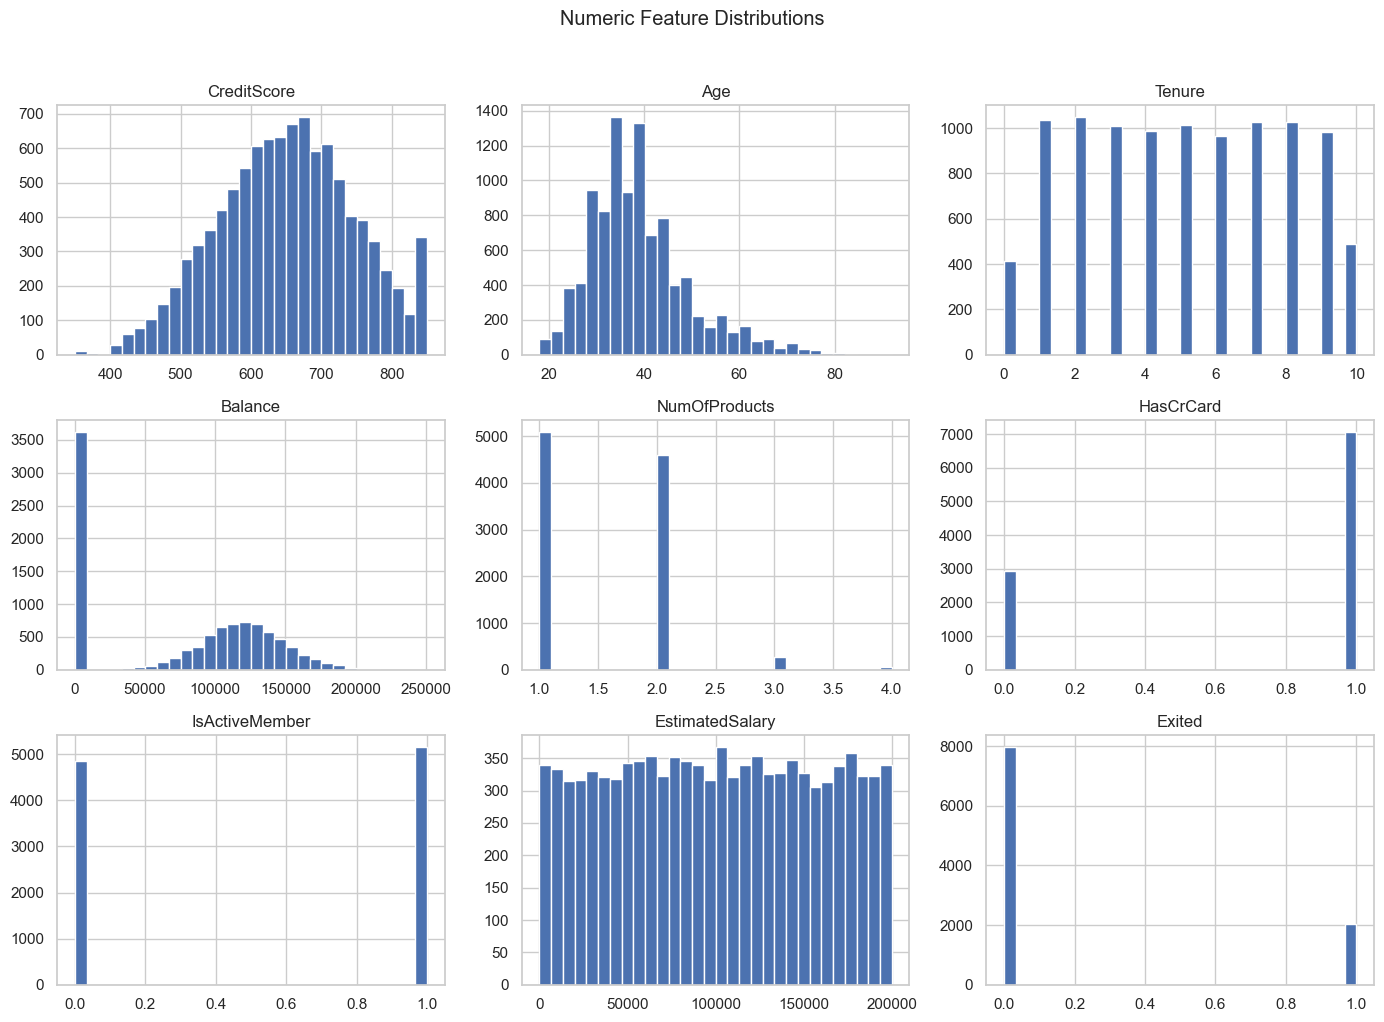

In [30]:
numeric_cols = model_df.select_dtypes(include=np.number).columns

model_df[numeric_cols].hist(figsize=(14, 10), bins=30)
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()


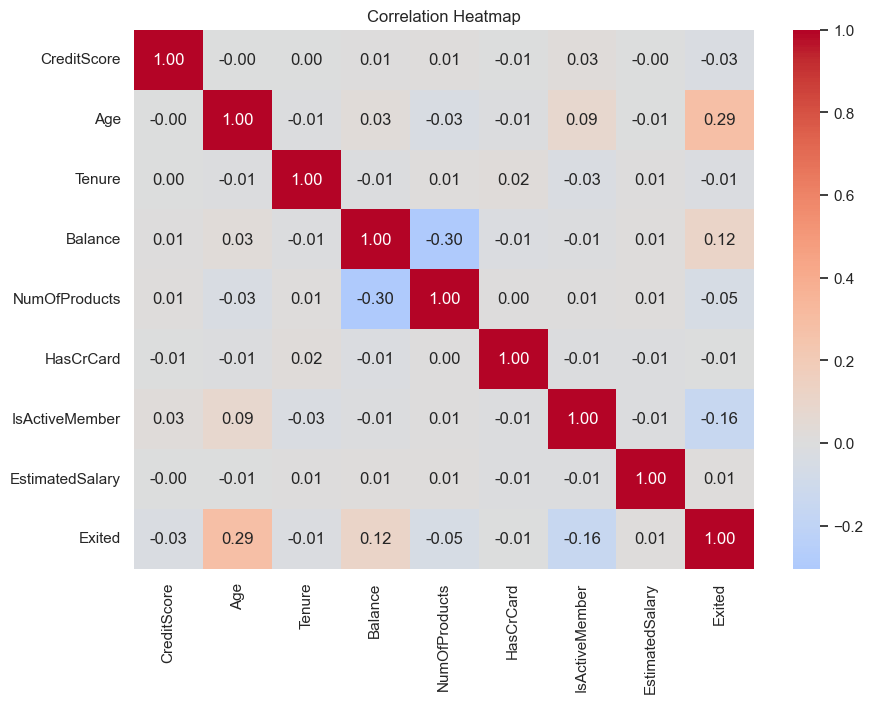

In [31]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    model_df.select_dtypes(include=np.number).corr(),
    annot=True, fmt=".2f", cmap="coolwarm", center=0
)
plt.title("Correlation Heatmap")
plt.show()


## 7. Train, Validation, and Test Split

The dataset is separated into training, validation, and test sets using stratified sampling.

- **Training set:** used to fit the neural network.
- **Validation set:** used to monitor training and select the decision threshold.
- **Test set:** reserved for final model evaluation.

The split is performed before fitting preprocessing transformations to prevent information leakage.


In [32]:
X = model_df.drop(columns=target)
y = model_df[target].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (7000, 10)
Validation: (1500, 10)
Test: (1500, 10)


## 8. Feature Preprocessing

Numerical features are standardized using `StandardScaler`, while categorical features are one-hot encoded.

The preprocessing transformer is fitted only on the training data and then applied to the validation and test sets.


In [33]:
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)
print("Processed shape:", X_train_processed.shape)


Categorical features: ['Geography', 'Gender']
Numeric features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Processed shape: (7000, 13)


## 9. Build Artificial Neural Network

The ANN uses fully connected dense layers with ReLU activation. Dropout layers are included to reduce overfitting, and the final sigmoid unit outputs the estimated probability of customer churn.


In [34]:
model = Sequential([
    Input(shape=(X_train_processed.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

## 10. Train the Model

The network is trained using binary cross-entropy loss and the Adam optimizer.

Early stopping monitors validation loss and restores the best model weights when validation performance stops improving.


In [35]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_processed, y_train,
    validation_data=(X_val_processed, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7911 - auc: 0.6716 - loss: 0.4821 - precision: 0.4313 - recall: 0.0792 - val_accuracy: 0.8200 - val_auc: 0.8051 - val_loss: 0.4070 - val_precision: 0.6957 - val_recall: 0.2092
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8167 - auc: 0.7630 - loss: 0.4306 - precision: 0.6551 - recall: 0.2118 - val_accuracy: 0.8360 - val_auc: 0.8295 - val_loss: 0.3854 - val_precision: 0.7206 - val_recall: 0.3203
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8284 - auc: 0.7918 - loss: 0.4096 - precision: 0.6812 - recall: 0.2966 - val_accuracy: 0.8440 - val_auc: 0.8461 - val_loss: 0.3650 - val_precision: 0.7432 - val_recall: 0.3595
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8346 - auc: 0.8086 - loss: 0.3949 - precision: 0.6872 - recall: 0.3450 - val_accuracy: 0.8453 - val_auc: 0.8588 - val_loss: 0.3538 - val_precision: 0.7056 - val_recall: 0.4150
Epoch 5/100
219/219 ━━━━━━━━

## 11. Training and Validation Curves


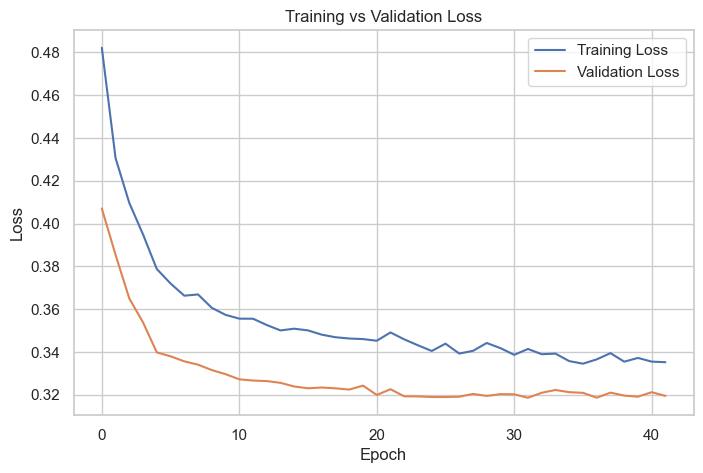

In [36]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


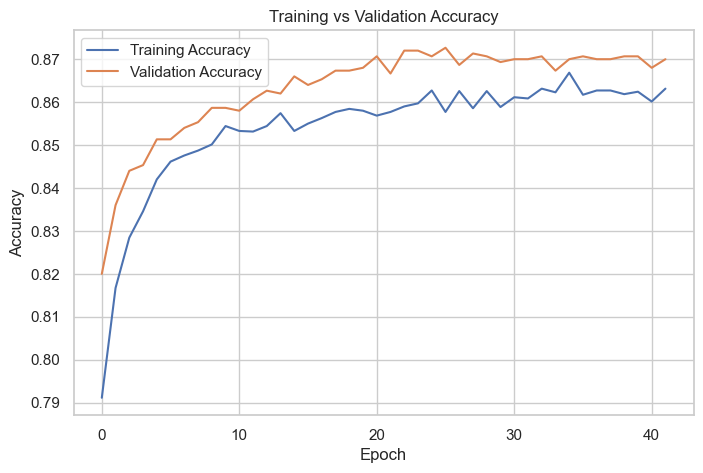

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


## 12. Evaluate Model on Test Set

Performance is evaluated using accuracy, precision, recall, F1 score, and ROC-AUC. These metrics provide a more complete assessment than accuracy alone because churners represent the minority class.


In [38]:
test_prob = model.predict(X_test_processed, verbose=0).ravel()
test_pred = (test_prob >= 0.50).astype(int)

base_metrics = {
    "Accuracy": accuracy_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred, zero_division=0),
    "Recall": recall_score(y_test, test_pred, zero_division=0),
    "F1 Score": f1_score(y_test, test_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, test_prob)
}
display(pd.DataFrame(base_metrics, index=["Score"]).T)
print(classification_report(y_test, test_pred, digits=4))


,Score
Accuracy,0.868000
Precision,0.783069
Recall,0.485246
F1 Score,0.599190
ROC-AUC,0.869228


              precision    recall  f1-score   support

           0     0.8802    0.9657    0.9210      1195
           1     0.7831    0.4852    0.5992       305

    accuracy                         0.8680      1500
   macro avg     0.8317    0.7255    0.7601      1500
weighted avg     0.8605    0.8680    0.8556      1500



## 13. Confusion Matrix


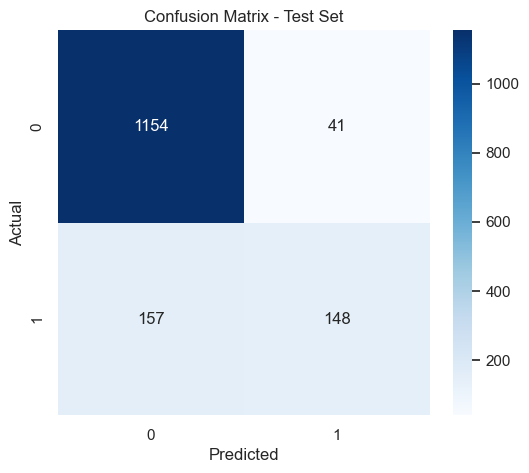

In [39]:
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 14. ROC Curve

The ROC curve evaluates how well the model separates churners from non-churners across all possible classification thresholds. ROC-AUC summarizes this discrimination ability in a single score.


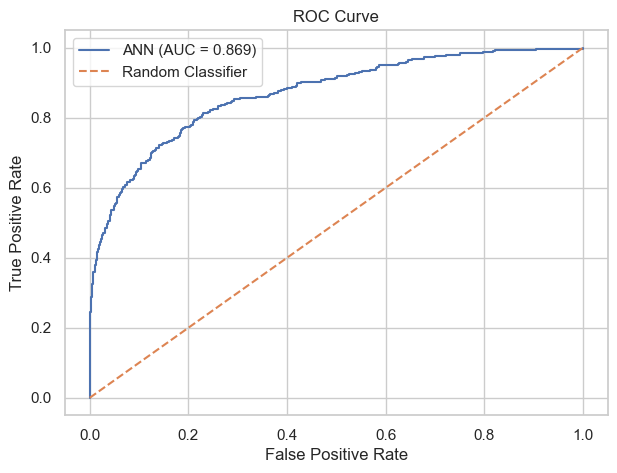

In [40]:
fpr, tpr, _ = roc_curve(y_test, test_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ANN (AUC = {roc_auc_score(y_test, test_prob):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## 15. Decision Threshold Analysis

A default probability threshold of `0.50` does not necessarily provide the best balance between precision and recall.

Threshold selection is performed using the **validation set**. The threshold producing the highest validation F1 score is then evaluated once on the untouched test set.


In [41]:
val_prob = model.predict(X_val_processed, verbose=0).ravel()

rows = []
for threshold in np.arange(0.20, 0.81, 0.05):
    pred = (val_prob >= threshold).astype(int)
    rows.append({
        "Threshold": round(float(threshold), 2),
        "Precision": precision_score(y_val, pred, zero_division=0),
        "Recall": recall_score(y_val, pred, zero_division=0),
        "F1": f1_score(y_val, pred, zero_division=0)
    })

threshold_df = pd.DataFrame(rows)
display(threshold_df)

best_threshold = float(threshold_df.loc[threshold_df["F1"].idxmax(), "Threshold"])
print(f"Best validation threshold by F1: {best_threshold:.2f}")


,Threshold,Precision,Recall,F1
0,0.20,0.497976,0.803922,0.615000
1,0.25,0.558313,0.735294,0.634697
2,0.30,0.620795,0.663399,0.641390
3,0.35,0.688172,0.627451,0.656410
4,0.40,0.716102,0.552288,0.623616
5,0.45,0.741784,0.516340,0.608863
6,0.50,0.790576,0.493464,0.607646
7,0.55,0.811429,0.464052,0.590437
8,0.60,0.831250,0.434641,0.570815
9,0.65,0.844444,0.372549,0.517007


Best validation threshold by F1: 0.35


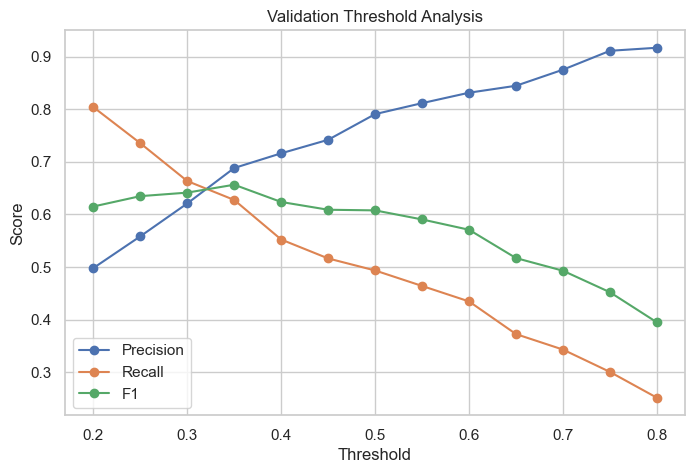

In [42]:
plt.figure(figsize=(8, 5))
for metric in ["Precision", "Recall", "F1"]:
    plt.plot(threshold_df["Threshold"], threshold_df[metric], marker="o", label=metric)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Validation Threshold Analysis")
plt.legend()
plt.show()


## 16. Compare Default and Optimized Thresholds


In [43]:
optimized_pred = (test_prob >= best_threshold).astype(int)

optimized_metrics = {
    "Accuracy": accuracy_score(y_test, optimized_pred),
    "Precision": precision_score(y_test, optimized_pred, zero_division=0),
    "Recall": recall_score(y_test, optimized_pred, zero_division=0),
    "F1 Score": f1_score(y_test, optimized_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, test_prob)
}

display(pd.DataFrame({
    "Threshold 0.50": base_metrics,
    f"Threshold {best_threshold:.2f}": optimized_metrics
}))


,Threshold 0.50,Threshold 0.35
Accuracy,0.868000,0.862000
Precision,0.783069,0.680147
Recall,0.485246,0.606557
F1 Score,0.599190,0.641248
ROC-AUC,0.869228,0.869228


## 17. Error Analysis

Misclassified test observations are inspected to understand where the ANN makes incorrect predictions and how confident those errors are.


In [44]:
errors = X_test.copy()
errors["Actual"] = y_test.values
errors["Predicted"] = optimized_pred
errors["Churn_Probability"] = test_prob
errors["Correct"] = errors["Actual"] == errors["Predicted"]

print("Misclassified customers:", (~errors["Correct"]).sum())
display(
    errors.loc[~errors["Correct"]]
    .sort_values("Churn_Probability", ascending=False)
    .head(15)
)


Misclassified customers: 207


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Actual,Predicted,Churn_Probability,Correct
4137,789,Germany,Male,51,3,104677.09,1,1,0,74265.38,0,1,0.846428,False
4457,713,Germany,Male,47,1,95994.98,1,1,0,197529.23,0,1,0.828190,False
2911,649,France,Female,52,8,49113.75,1,1,0,41858.43,0,1,0.809658,False
2220,714,Germany,Female,49,5,140510.89,1,1,0,141914.94,0,1,0.805779,False
6052,452,Germany,Male,52,1,98443.14,2,0,0,92033.98,0,1,0.797154,False
3653,688,Germany,Female,46,0,74458.25,1,0,1,6866.31,0,1,0.766994,False
5257,807,Germany,Female,31,1,141069.18,3,1,1,194257.11,0,1,0.759811,False
8173,757,Germany,Male,31,1,127320.36,3,1,0,163170.32,0,1,0.738361,False
1698,485,Germany,Male,51,7,144244.59,2,1,0,51113.14,0,1,0.728106,False
18,587,Spain,Male,45,6,0.00,1,0,0,158684.81,0,1,0.715864,False


## 18. Key Findings

* The dataset contains **10,000 customer records**, with an overall churn rate of approximately **20.37%**, making churn the minority class.
* The ANN achieved a **ROC-AUC of approximately 0.87**, indicating good ability to distinguish between customers who churn and those who remain.
* At the default **0.50 decision threshold**, the model achieved approximately **86.8% accuracy**, **78.3% precision**, **48.5% recall**, and an **F1 score of 59.9%**.
* The relatively low recall showed that the default threshold missed a substantial proportion of actual churners despite high overall accuracy.
* Validation-set threshold analysis selected **0.35** as the preferred threshold based on F1 score.
* At the optimized **0.35 threshold**, recall increased to approximately **60.7%** and F1 improved to approximately **64.1%**, while accuracy decreased only slightly to approximately **86.2%**.
* The threshold adjustment demonstrates the practical trade-off between precision and recall and shows why accuracy alone is insufficient for evaluating an imbalanced classification problem.
* Early stopping prevented unnecessary training and restored the model weights associated with the best validation loss.


## 19. Conclusion

This project demonstrated an end-to-end binary classification workflow using an **Artificial Neural Network (ANN)** for customer churn prediction.

The model showed good overall discrimination with a ROC-AUC of approximately **0.87**. Although the default 0.50 classification threshold produced high accuracy and precision, its recall was comparatively low. Selecting the decision threshold using validation data improved recall and F1 score while preserving similar overall accuracy.

The results highlight the importance of evaluating classification models using metrics beyond accuracy. For an imbalanced problem such as customer churn, precision, recall, F1 score, ROC-AUC, and decision-threshold analysis provide a more complete assessment of model behavior.

Overall, the ANN provides a useful baseline for identifying customers at risk of churn and demonstrates how neural networks can be applied to structured tabular classification problems.